# Retail Sales Intelligence Analysis

## Objective
To analyze retail sales data to identify revenue trends, customer segmentation patterns, regional performance, and operational efficiency.

## Tools Used
- Python (Pandas, Matplotlib)
- Jupyter Notebook

In [1]:

!pip install pandas numpy matplotlib seaborn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
import pandas as pd

file_path = r"C:\Users\Super-A\Documents\Data_Projects\train.csv"

df = pd.read_csv(file_path)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


## 1. Data Inspection & Cleaning

In [4]:
df.shape

(9800, 18)

In [5]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [7]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [8]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

## 2. Revenue Trend Analysis

In [9]:
total_revenue = df['Sales'].sum()
total_revenue

np.float64(2261536.7827)

In [10]:
average_sales = df['Sales'].mean()
average_sales

np.float64(230.76905945918367)

In [11]:
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.head()

Month
2015-01    14205.707
2015-02     4519.892
2015-03    55205.797
2015-04    27906.855
2015-05    23644.303
Freq: M, Name: Sales, dtype: float64

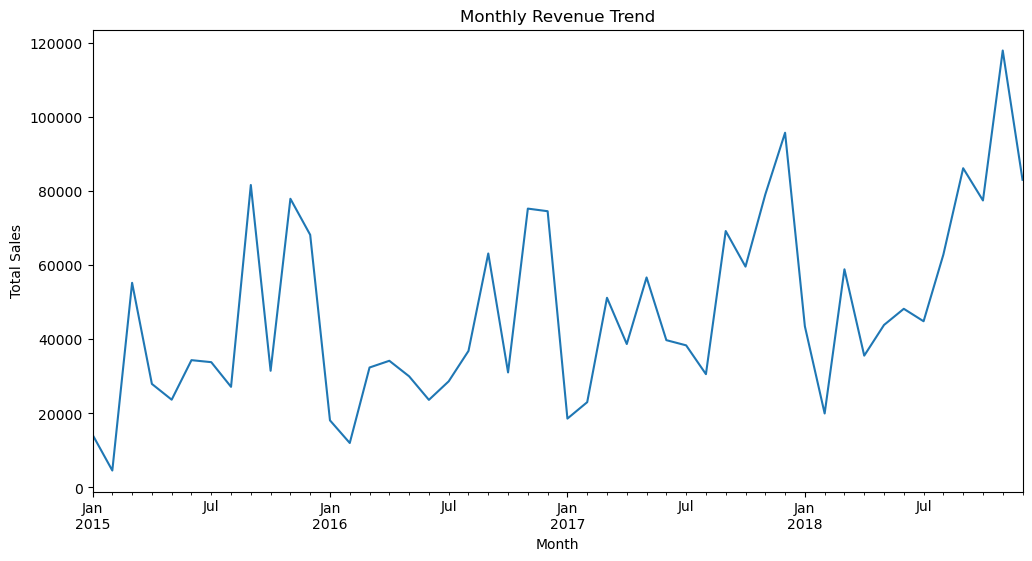

In [12]:
monthly_sales.plot(figsize=(12,6))
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.show()

In [13]:
df['Year'] = df['Order Date'].dt.year

yearly_sales = df.groupby('Year')['Sales'].sum()

yearly_sales

Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

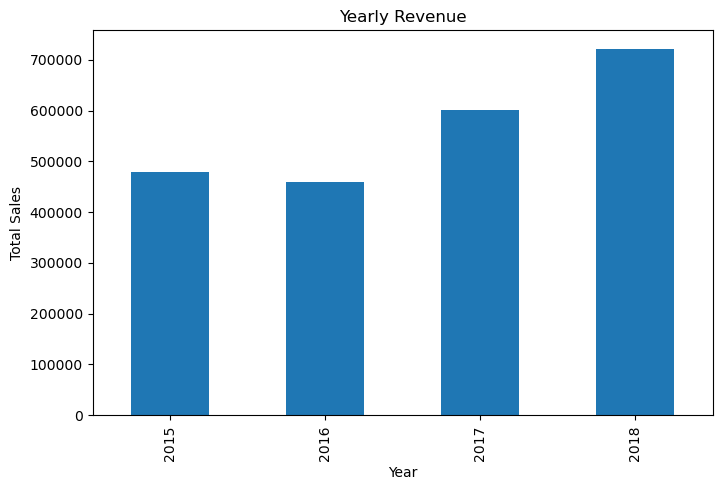

In [14]:
yearly_sales.plot(kind='bar', figsize=(8,5))
plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.show()

## 3. Product Performance Analysis

In [15]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

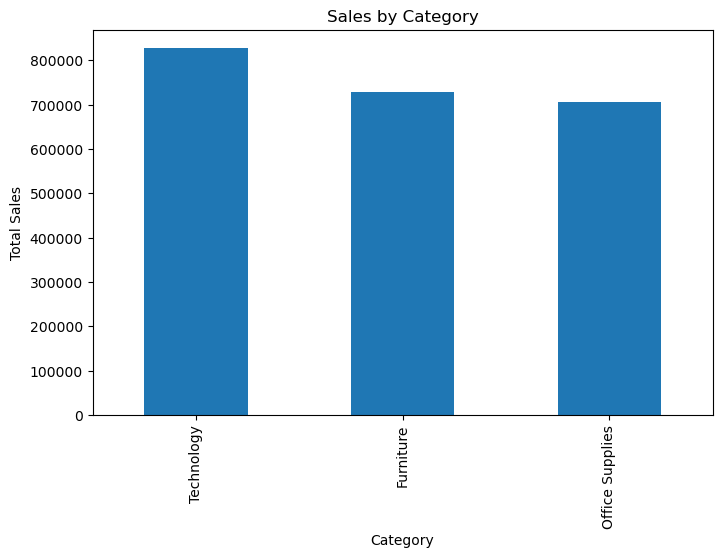

In [16]:
category_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

In [17]:
sub_category_sales = df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)

sub_category_sales.head(10)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64

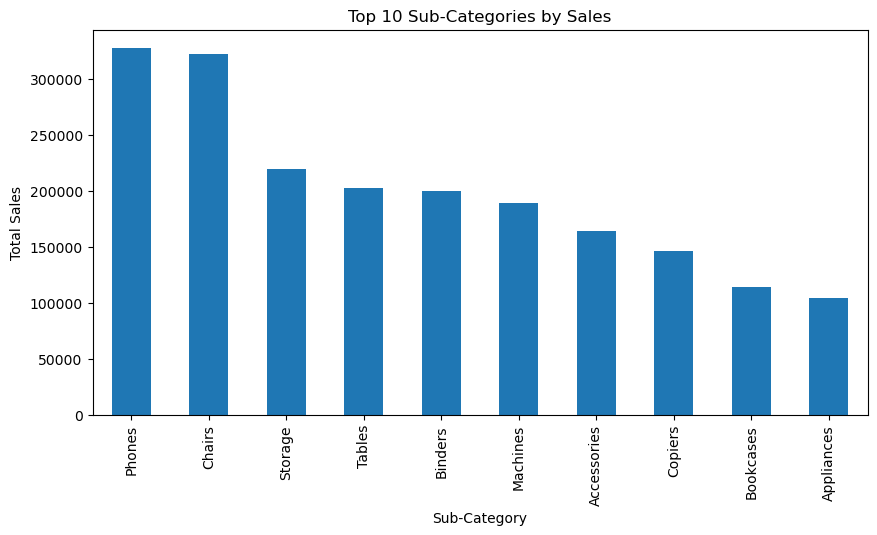

In [18]:
sub_category_sales.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Sub-Categories by Sales")
plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.show()

## 4. Regional Performance Analysis

In [19]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

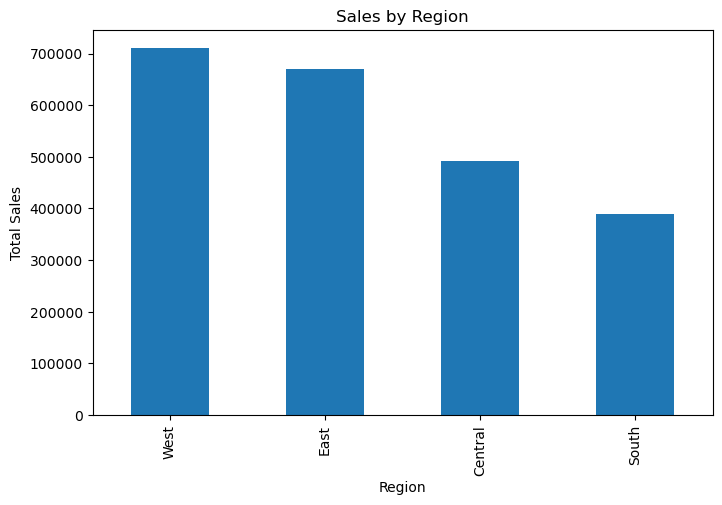

In [20]:
region_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.show()

## 5. Operational Efficiency (Delivery Analysis)

In [21]:
df['Delivery Days'] = (df['Ship Date'] - df['Order Date']).dt.days

df['Delivery Days'].describe()

count    9800.000000
mean        3.961122
std         1.749614
min         0.000000
25%         3.000000
50%         4.000000
75%         5.000000
max         7.000000
Name: Delivery Days, dtype: float64

In [22]:
region_delivery = df.groupby('Region')['Delivery Days'].mean().sort_values(ascending=False)

region_delivery

Region
Central    4.065876
South      3.961202
West       3.930255
East       3.910233
Name: Delivery Days, dtype: float64

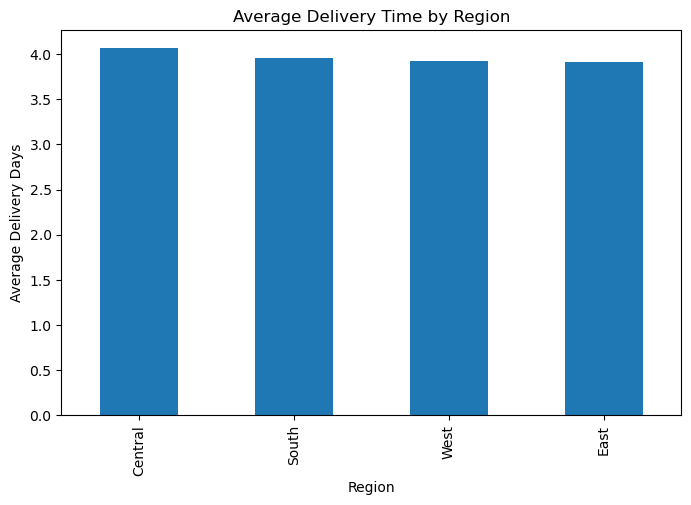

In [23]:
region_delivery.plot(kind='bar', figsize=(8,5))
plt.title("Average Delivery Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Delivery Days")
plt.show()

## 6. Customer Segment Analysis

In [24]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

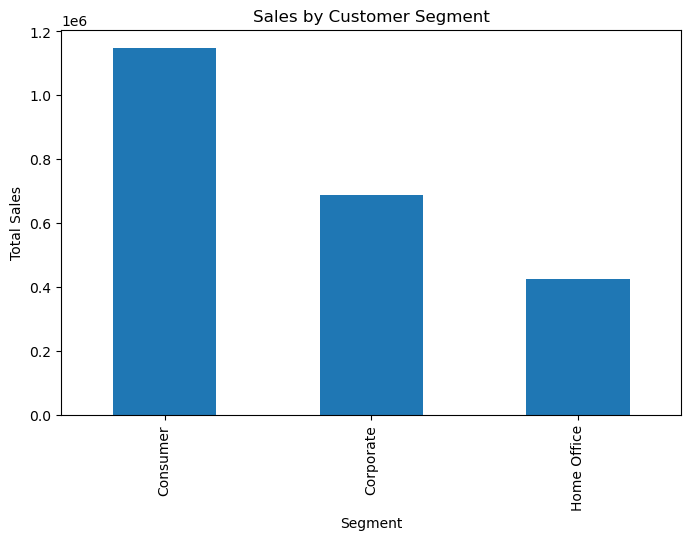

In [25]:
segment_sales.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Customer Segment")
plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.show()

## 7. Customer Concentration Analysis

In [26]:
top_customers = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)

top_customers.head(10)

Customer Name
Sean Miller           25043.050
Tamara Chand          19052.218
Raymond Buch          15117.339
Tom Ashbrook          14595.620
Adrian Barton         14473.571
Ken Lonsdale          14175.229
Sanjit Chand          14142.334
Hunter Lopez          12873.298
Sanjit Engle          12209.438
Christopher Conant    12129.072
Name: Sales, dtype: float64